# Segmentação de clientes com K-means

**Autor:** Prof. Dr. Sergio Antônio Andrade de Freitas  
**Material da disciplina:** FGA0083 — Aprendizado de Máquina, UnB

## Objetivo e dados

Padronizar quatro medidas não redundantes e interpretar quatro segmentos nas unidades originais.

**Pergunta-guia:** Os grupos diferem principalmente em renda ou em gastos?

Execute as células na ordem e interprete os resultados antes de fazer o exercício.

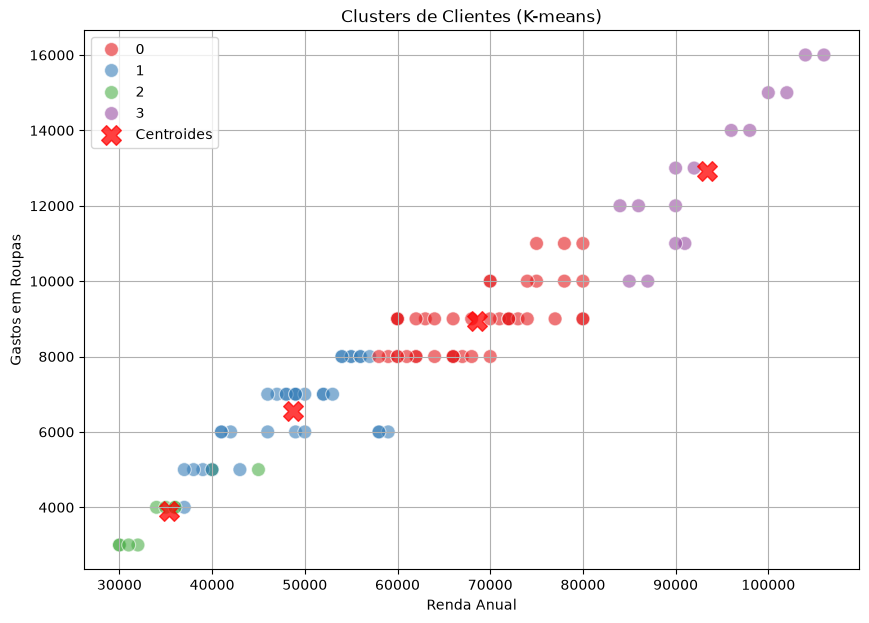

Tamanho dos grupos: {0: 41, 1: 33, 2: 11, 3: 15}
         Renda Anual  Gastos em Roupas  Gastos em Eletrônicos  Gastos em Saúde
Cluster                                                                       
0            68609.8            8951.2                 6836.6           7739.0
1            48727.3            6545.5                 4715.2           5715.2
2            35363.6            3909.1                 1390.9           2163.6
3            93400.0           12933.3                 9340.0          10340.0


In [1]:
# parte 1
from pathlib import Path

import pandas as pd
from sklearn.preprocessing import StandardScaler


def resolve_data_path(filename: str, must_exist: bool = True) -> Path:
    candidates = [
        Path.cwd() / "data" / filename,
        Path.cwd().parent / "data" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()

    if must_exist:
        raise FileNotFoundError(
            f"Nao foi possivel localizar o arquivo de dados '{filename}' em {candidates}."
        )

    for candidate in candidates:
        if candidate.parent.exists():
            return candidate.resolve()

    return candidates[0].resolve()


# Carregar os dados
data = pd.read_csv(resolve_data_path("14.1 - customer_data.csv"))

# Selecionar as colunas relevantes
X = data[['Renda Anual', 'Gastos em Roupas', 'Gastos em Eletrônicos', 'Gastos em Saúde']]

# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# parte 2
from sklearn.cluster import KMeans

# Aplicar K-means
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
kmeans.fit(X_scaled)
data['Cluster'] = kmeans.labels_

# Centroides dos clusters
centroids = kmeans.cluster_centers_

# parte 3
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizacao dos clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Renda Anual', y='Gastos em Roupas', hue='Cluster', data=data, palette='Set1', s=100, alpha=0.6)
centroids_originais = scaler.inverse_transform(centroids)
plt.scatter(centroids_originais[:, 0], centroids_originais[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroides')
plt.title('Clusters de Clientes (K-means)')
plt.xlabel('Renda Anual')
plt.ylabel('Gastos em Roupas')
plt.legend()
plt.grid(True)
plt.show()
print('Tamanho dos grupos:', data['Cluster'].value_counts().sort_index().to_dict())
print(data.groupby('Cluster')[X.columns].mean().round(1))

## Investigação complementar

Compare a nova medida com a figura ou o resultado anterior. Explique qualquer diferença observada.

In [2]:
import numpy as np
from sklearn.metrics import silhouette_score
for k in range(2, 7):
    with np.errstate(divide='ignore', over='ignore', invalid='ignore'):
        candidato = KMeans(n_clusters=k, random_state=0, n_init=10).fit(X_scaled)
        silhueta = silhouette_score(X_scaled, candidato.labels_)
    assert np.isfinite(silhueta), 'Silhueta não finita'
    print(f'k={k}: silhueta={silhueta:.3f}')

k=2: silhueta=0.485
k=3: silhueta=0.495
k=4: silhueta=0.500
k=5: silhueta=0.496
k=6: silhueta=0.495


## Interpretação e limites

As duas dimensões do gráfico não exibem toda a distância usada pelo modelo. `Gastos em Alimentos` é exatamente `Gastos em Roupas + 1000` neste arquivo; duplicá-lo daria peso extra à mesma informação.

## Exercício

Compare k=2 a 6 com silhueta e discuta estabilidade dos perfis.

Registre a hipótese, a mudança realizada, a métrica ou figura observada e uma conclusão que os dados de fato sustentem.